In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tapas_gmm_modified.policy.models.tpgmm import (
    ReconstructionStrategy, 
    FittingStage,
    InitStrategy,
)
from tapas_gmm_modified.utils.robot_trajectory import RobotTrajectory
from tapas_gmm_modified.policy.gmm import GMMPolicy, GMMPolicyConfig
from tapas_gmm_modified.utils.observation import SceneObservation, dict_to_tensordict
from tapas_gmm_modified.policy.models.tpgmm import (
    ModelType,
    FittingStage,
    InitStrategy,
    TPGMMConfig,
    AutoTPGMMConfig,
    AutoTPGMM,
    Demos,
    FrameSelectionConfig,
    DemoSegmentationConfig,
    CascadeConfig,
)

from tapas_gmm_modified.dataset.demos import Demos
from tapas_gmm_modified.viz.gmm import plot_hmm_transition_matrix

np.set_printoptions(precision=2)

plt.style.use('default')

from matplotlib import rc
rc('animation', html='jshtml')

2026-07-29 15:37:06.617 | INFO     |  Running on cpu


/home/jangruhnert/.conda/envs/hecarim/lib/python3.10/site-packages/riepybdlib/data.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_listdir


In [ ]:
from heca.agents.experts.tapas import TapasAgent
from heca.scenes.ogbench.scene import OGScene
agent_cfg = TapasAgent.Config(
    tag="open_drawer",
    scene=OGScene.Config(),
    policy=GMMPolicyConfig(
        suffix="release",
        model=AutoTPGMMConfig(
            tpgmm=TPGMMConfig(
                n_components=20,
                model_type=ModelType.HMM,
                use_riemann=True,
                add_time_component=True,
                add_action_component=False,
                position_only=False,
                add_gripper_action=True,
                reg_shrink=1e-2,  # test
                reg_diag=1e-4,  # test 1
                reg_diag_gripper=2e-2,
                reg_em_finish_shrink=1e-2,
                reg_em_finish_diag=2e-4,  # test
                reg_em_finish_diag_gripper=2e-2,
                trans_cov_mask_t_pos_corr=False,
                em_steps=50,
                fix_first_component=False,  # True maybe
                fix_last_component=False,  # True maybe
                reg_init_diag=5e-4,  # 5
                heal_time_variance=False,
            ),
            frame_selection=FrameSelectionConfig(
                init_strategy=InitStrategy.TIME_BASED,
                fitting_actions=(FittingStage.INIT,),
                use_bic=False,
                drop_redundant_frames=False,
                rel_score_threshold=0.0,
                gt_frames=None,  # Frames per segment
            ),
            demos_segmentation=DemoSegmentationConfig(
                gripper_based=False,
                distance_based=False,
                velocity_based=True,
                repeat_final_step=0,  # 1
                repeat_first_step=0,
                components_prop_to_len=True,
                velocity_threshold=0.05,
            ),
            cascade=CascadeConfig(
                kl_keep_time_dim=True,
                kl_keep_rotation_dim=True,
            ),
        ),
        time_based=True,
        predict_dx_in_xdx_models=False,
        binary_gripper_action=False,
        binary_gripper_closed_threshold=0.0,
        dbg_prediction=False,
        force_overwrite_checkpoint_config=True,  # TODO:  otherwise it doesnt work
        time_scale=1.0,
        postprocess_prediction=True,  # TODO:  abs quaternions if False else delta quaternions
        invert_prediction_batch=False,
        return_full_batch=True,
        batch_predict_in_t_models=True,
    ),
    use_gt=True,
    gt_frames=[[0, 4], [4, 2], [4, 7]],
)
agent = TapasAgent.get(agent_cfg, auto_load=True)
print(agent_cfg.policy.model.frame_selection.gt_frames)
selections = [0, 1, 4, 6, 7]

2026-07-29 15:37:17.998 | INFO     | heca.misc.logger:info:37 - Running on cpu


TypeError: Can't instantiate abstract class OGBenchScene with abstract methods description, ee, entities, to_dc_scene

In [ ]:
observations = agent.load_demos(selections)

demos = Demos(
    observations,
    add_init_ee_pose_as_frame=True,
    add_world_frame=False,
    frames_from_keypoints=False,
    kp_indeces=None,
    enforce_z_up=False,
    modulo_object_z_rotation=False,
    make_quats_continuous=True,
)  # type: ignore
print("n_trajs", demos.n_trajs)
print("n_frames", demos.n_frames)
demos.frame_names


n_trajs 5
n_frames 8


('ee_init',
 'block_0',
 'button_0',
 'button_1',
 'drawer_handle',
 'window_handle',
 'block_0_target',
 'ee_target')

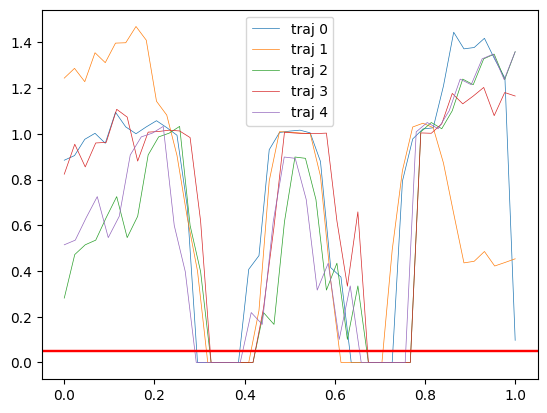

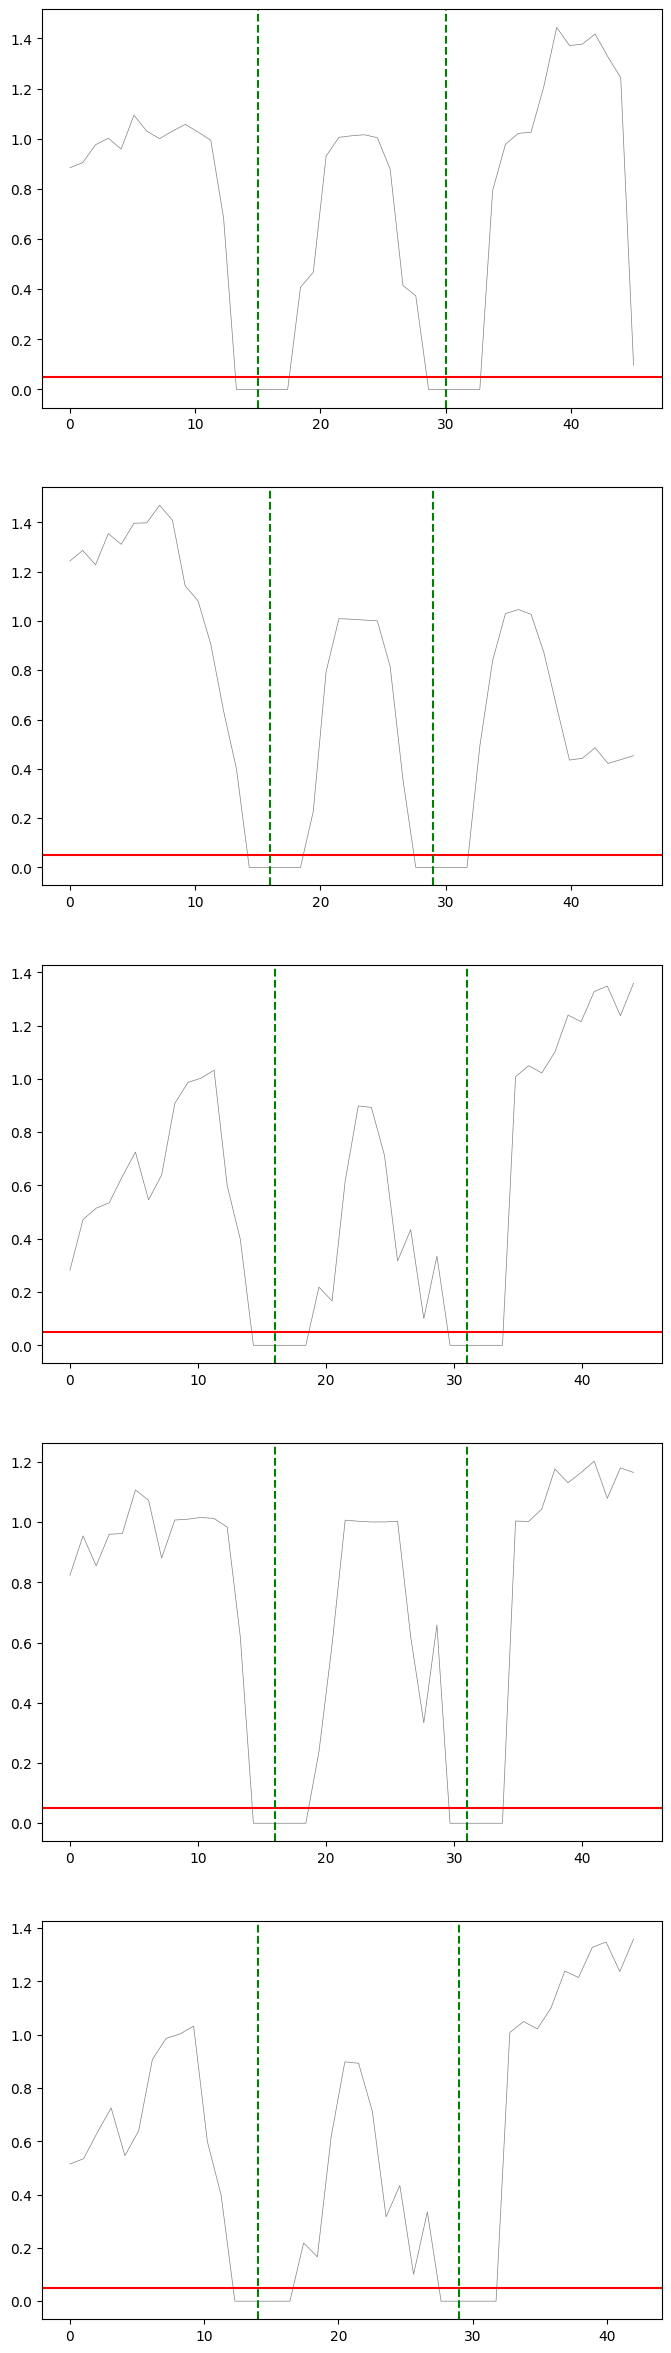

Time-based init:   0%|          | 0/7 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/7 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/7 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/7 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/7 [00:00<?, ?it/s]

...

Fitting segments:   0%|          | 0/3 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/7 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/6 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/6 [00:00<?, ?it/s]

((array([[1.88e+014, 2.07e+014, 1.33e+013, 2.43e+010, 1.59e+006, 2.65e+001,
          3.47e-006, 5.58e-014, 1.38e-019, 1.40e-025, 3.69e-033, 5.01e-047,
          2.00e-074, 1.40e-119, 3.66e-125, 5.93e+013, 7.01e+013, 3.89e+011,
          6.76e+006, 3.60e-001, 2.32e-011, 1.14e-024, 2.17e-055, 4.07e-074,
          2.49e-090, 7.91e-109, 1.80e-139, 1.20e-189, 1.80e-273, 5.98e-279,
          3.24e+014, 4.38e+014, 1.14e+014, 7.12e+012, 9.54e+010, 1.82e+008,
          2.35e+003, 4.60e-003, 5.83e-008, 2.91e-014, 9.35e-022, 1.09e-040,
          8.30e-085, 2.37e-138, 8.48e-145, 9.69e+013, 1.84e+014, 1.86e+013,
          1.59e+012, 7.26e+009, 2.57e+005, 4.09e+000, 7.79e-009, 2.65e-015,
          2.72e-022, 1.45e-032, 5.46e-050, 2.19e-089, 9.03e-155, 4.78e-161,
          2.81e+014, 2.06e+014, 3.52e+013, 1.04e+012, 4.48e+008, 1.09e+006,
          1.60e+002, 5.05e-001, 1.12e-005, 1.02e-011, 5.25e-019, 9.55e-038,
          1.41e-081, 5.60e-135, 1.90e-141],
         [9.03e+010, 1.53e+013, 2.43e+014, 1

In [ ]:
agent.model.fit_trajectories(demos, fix_frames=True,
                       init_strategy=InitStrategy.TIME_BASED,
                       fitting_actions=(FittingStage.INIT,))


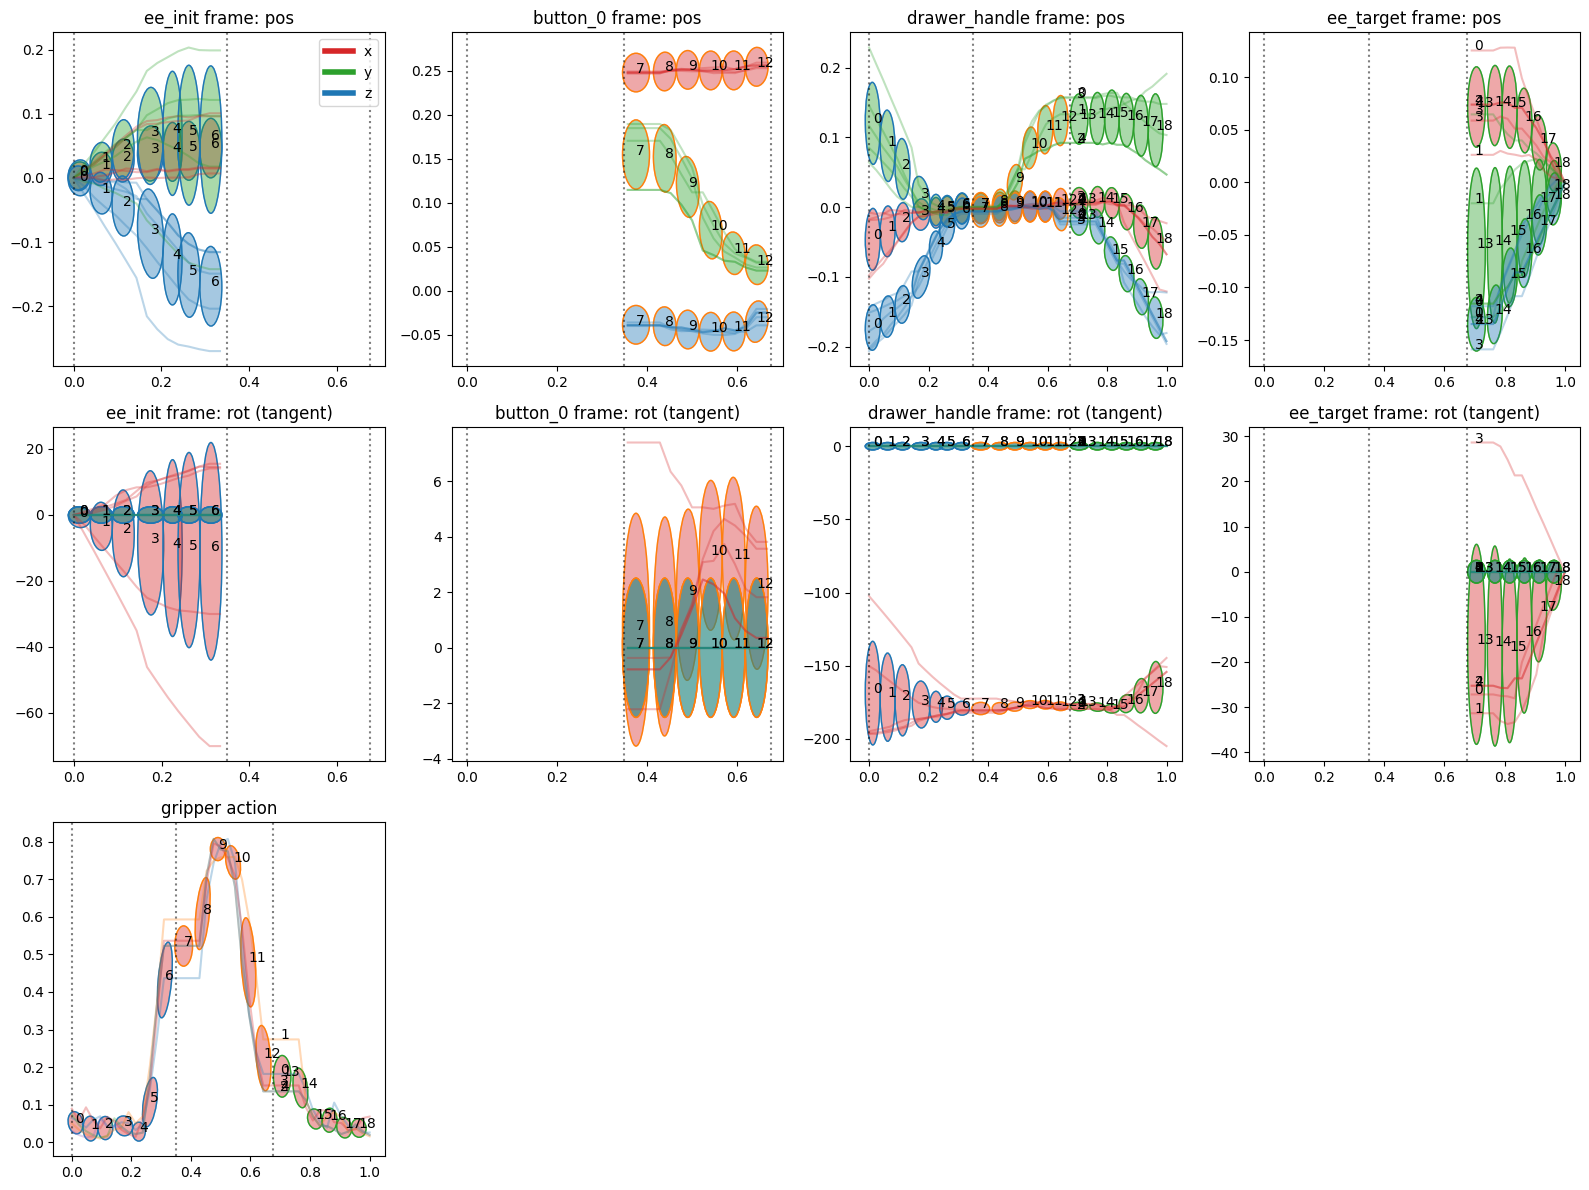

In [ ]:
agent.model.plot_model(scatter=True, annotate_gaussians=True, annotate_trajs=True, mean_as_base=False)


In [ ]:
agent.model.fit_trajectories(demos, fix_frames=True, fitting_actions=(FittingStage.EM_HMM, ))


Fitting segments:   0%|          | 0/3 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

((array([[1.00e+000, 9.62e-001, 4.46e-003, 7.08e-012, 8.70e-031, 9.43e-063,
          2.57e-109, 1.33e-168, 1.50e-241, 0.00e+000, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 0.00e+000, 1.00e+000, 1.00e+000, 8.29e-005,
          3.06e-021, 1.89e-055, 1.20e-117, 1.98e-226, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000,
          1.00e+000, 9.89e-001, 5.01e-001, 9.18e-003, 6.43e-011, 1.74e-029,
          6.31e-059, 8.06e-102, 3.72e-157, 7.57e-224, 7.36e-293, 0.00e+000,
          0.00e+000, 0.00e+000, 0.00e+000, 1.00e+000, 1.00e+000, 9.51e-001,
          2.77e-002, 7.41e-014, 4.96e-040, 3.78e-080, 6.96e-135, 1.56e-204,
          2.74e-286, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000,
          1.00e+000, 9.20e-001, 1.52e-001, 2.14e-006, 7.60e-018, 2.46e-035,
          1.60e-061, 1.83e-100, 5.89e-152, 4.49e-215, 2.08e-281, 0.00e+000,
          0.00e+000, 0.00e+000, 0.00e+000],
         [6.64e-197, 3.80e-002, 9.95e-001, 3

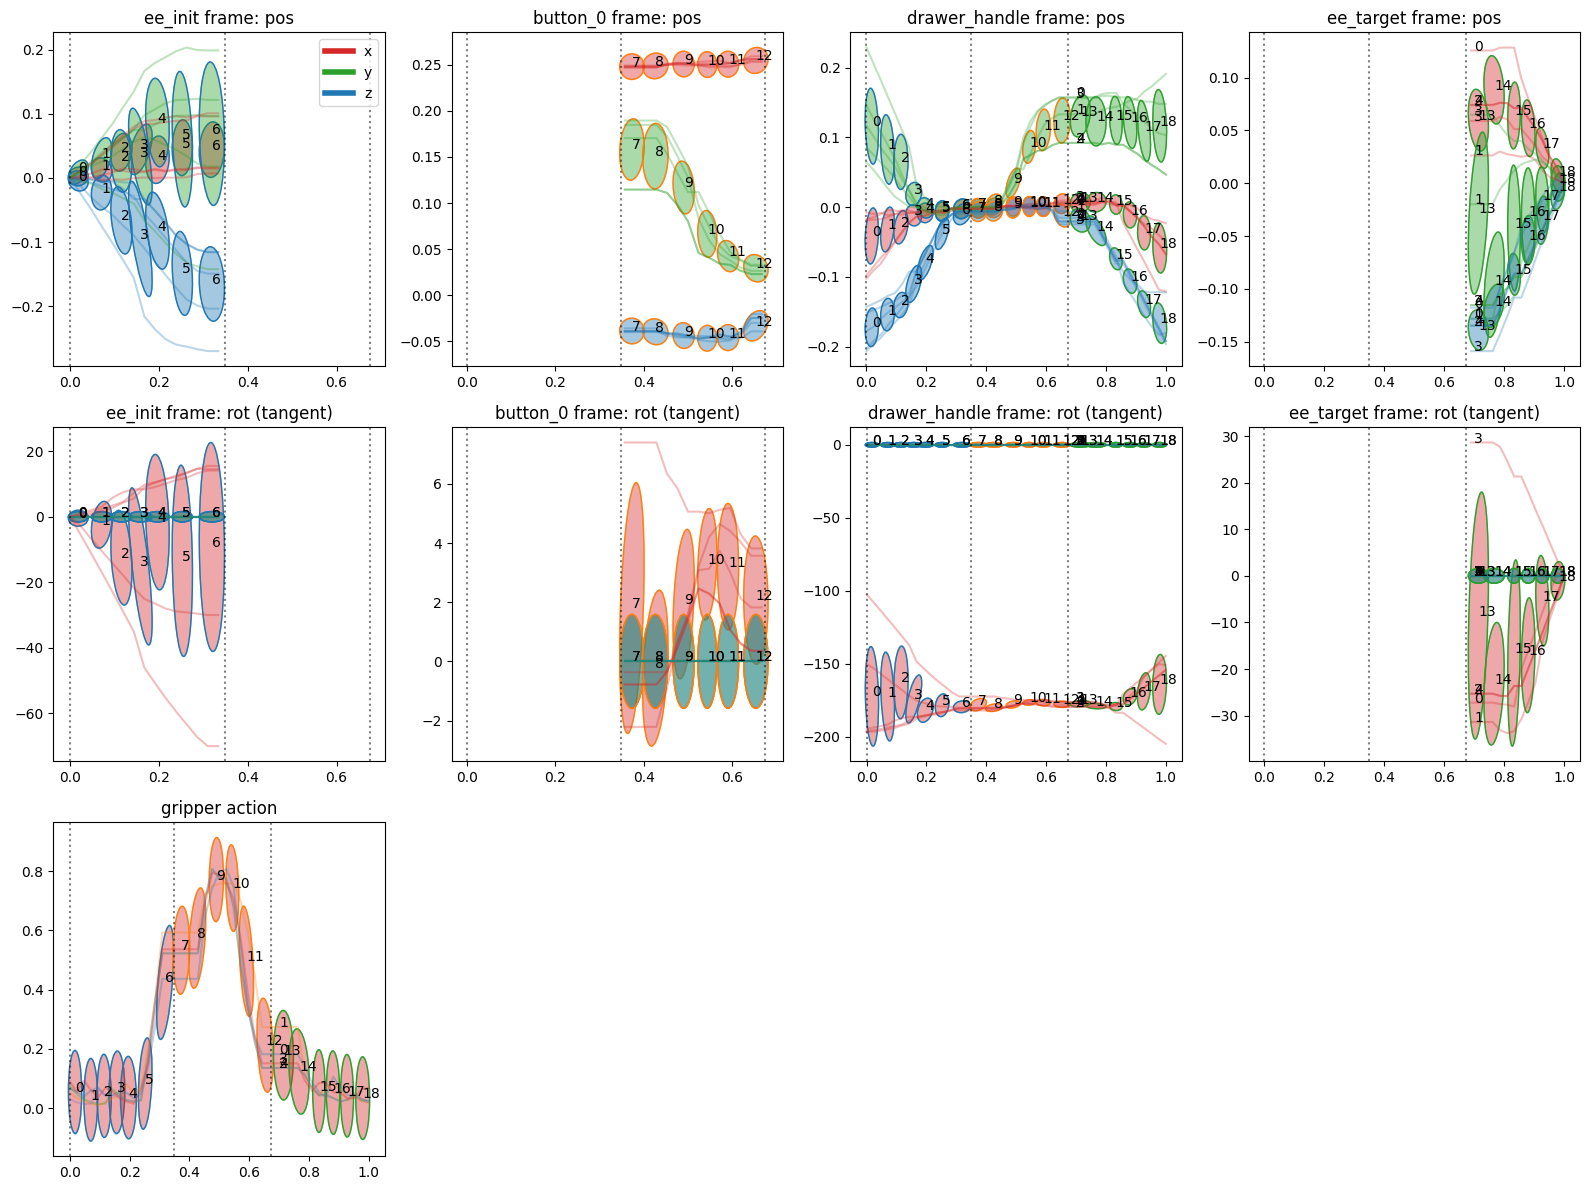

In [ ]:
agent.model.plot_model(
    scatter=True, annotate_gaussians=True, annotate_trajs=True, mean_as_base=False, time_based=True,
)

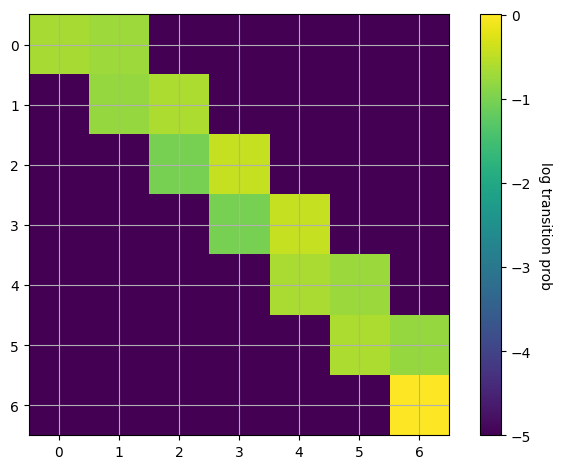

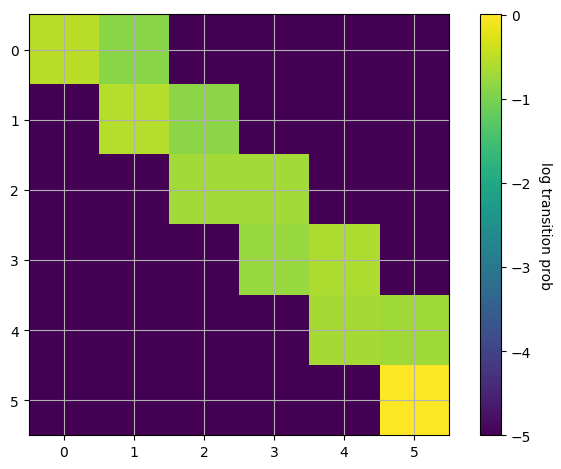

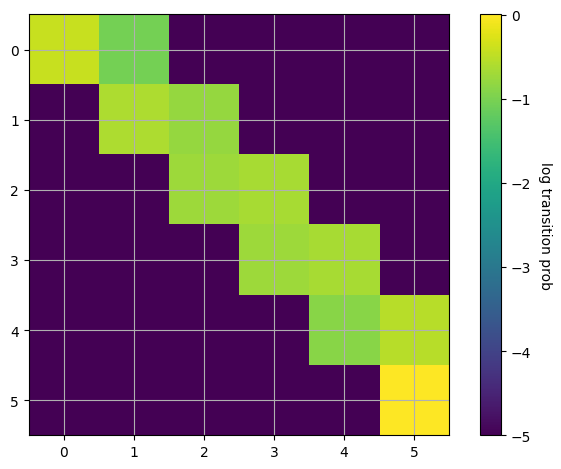

In [ ]:
agent.model.plot_hmm_transition_matrix()

In [ ]:
agent.save()

2026-07-23 14:16:45.720 | INFO     | heca.misc.logger:info:37 - Saving <class 'heca.agents.experts.tapas.TapasAgent'> to /home/jangruhnert/Documents/GitHub/heca/data/agents/tapas/open_drawer
2026-07-23 14:16:45.720 | INFO     | heca.misc.logger:info:37 - Saving tapas policy to: /home/jangruhnert/Documents/GitHub/heca/data/agents/tapas/open_drawer/policy_gt.pt


In [ ]:
seg_local_marginals, seg_trans_marginals, seg_trans_marg_container, seg_joint_models, cascaded_hmms, (reconstructions, original_trajectories, extras) = agent.model.reconstruct(
    strategy=ReconstructionStrategy.GMR,
    use_ss=False)


Transforming marginals:   0%|          | 0/5 [00:00<?, ?it/s]

Joining marginals:   0%|          | 0/5 [00:00<?, ?it/s]

Transforming marginals:   0%|          | 0/5 [00:00<?, ?it/s]

Joining marginals:   0%|          | 0/5 [00:00<?, ?it/s]

Transforming marginals:   0%|          | 0/5 [00:00<?, ?it/s]

Joining marginals:   0%|          | 0/5 [00:00<?, ?it/s]

GMR:   0%|          | 0/5 [00:00<?, ?it/s]

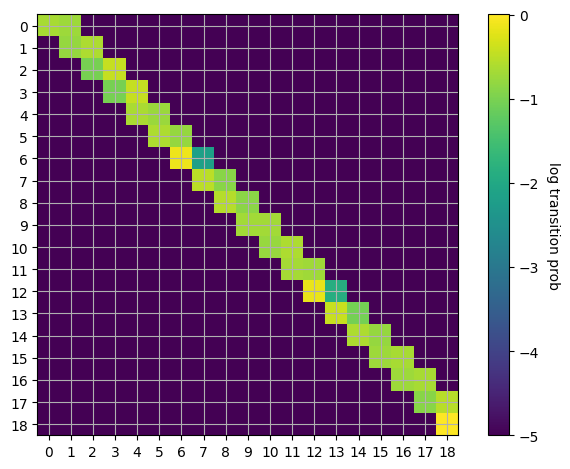

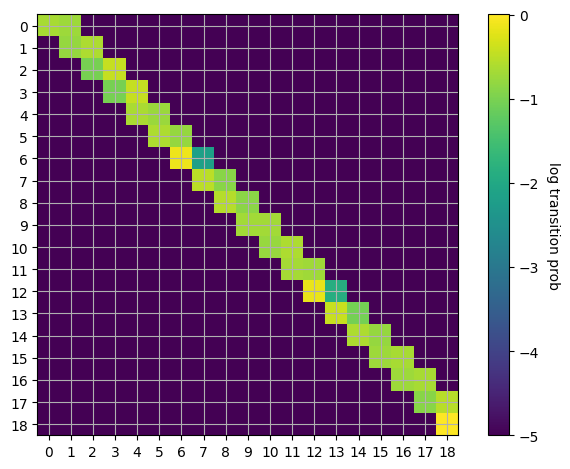

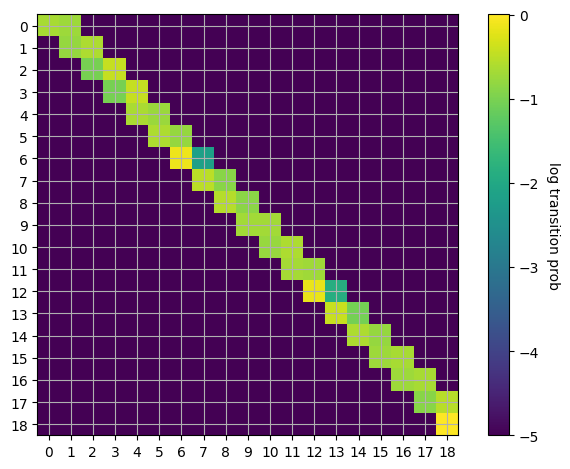

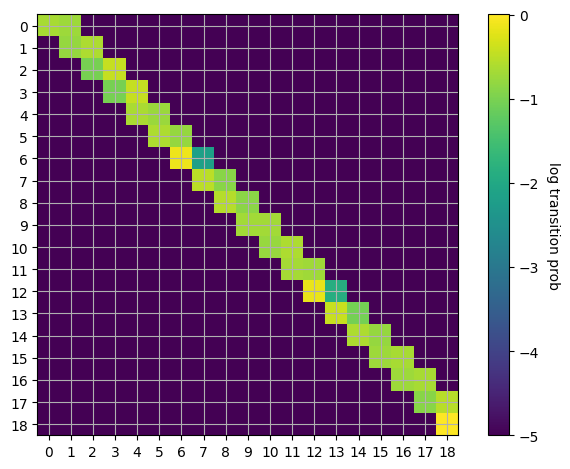

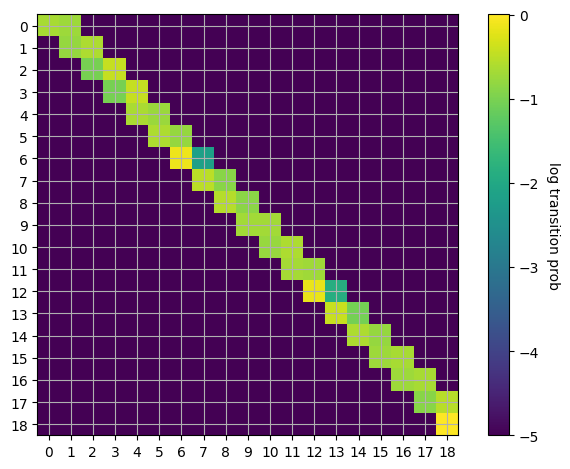

In [ ]:
for cascaded_hmm in cascaded_hmms:
    plot_hmm_transition_matrix(cascaded_hmm)

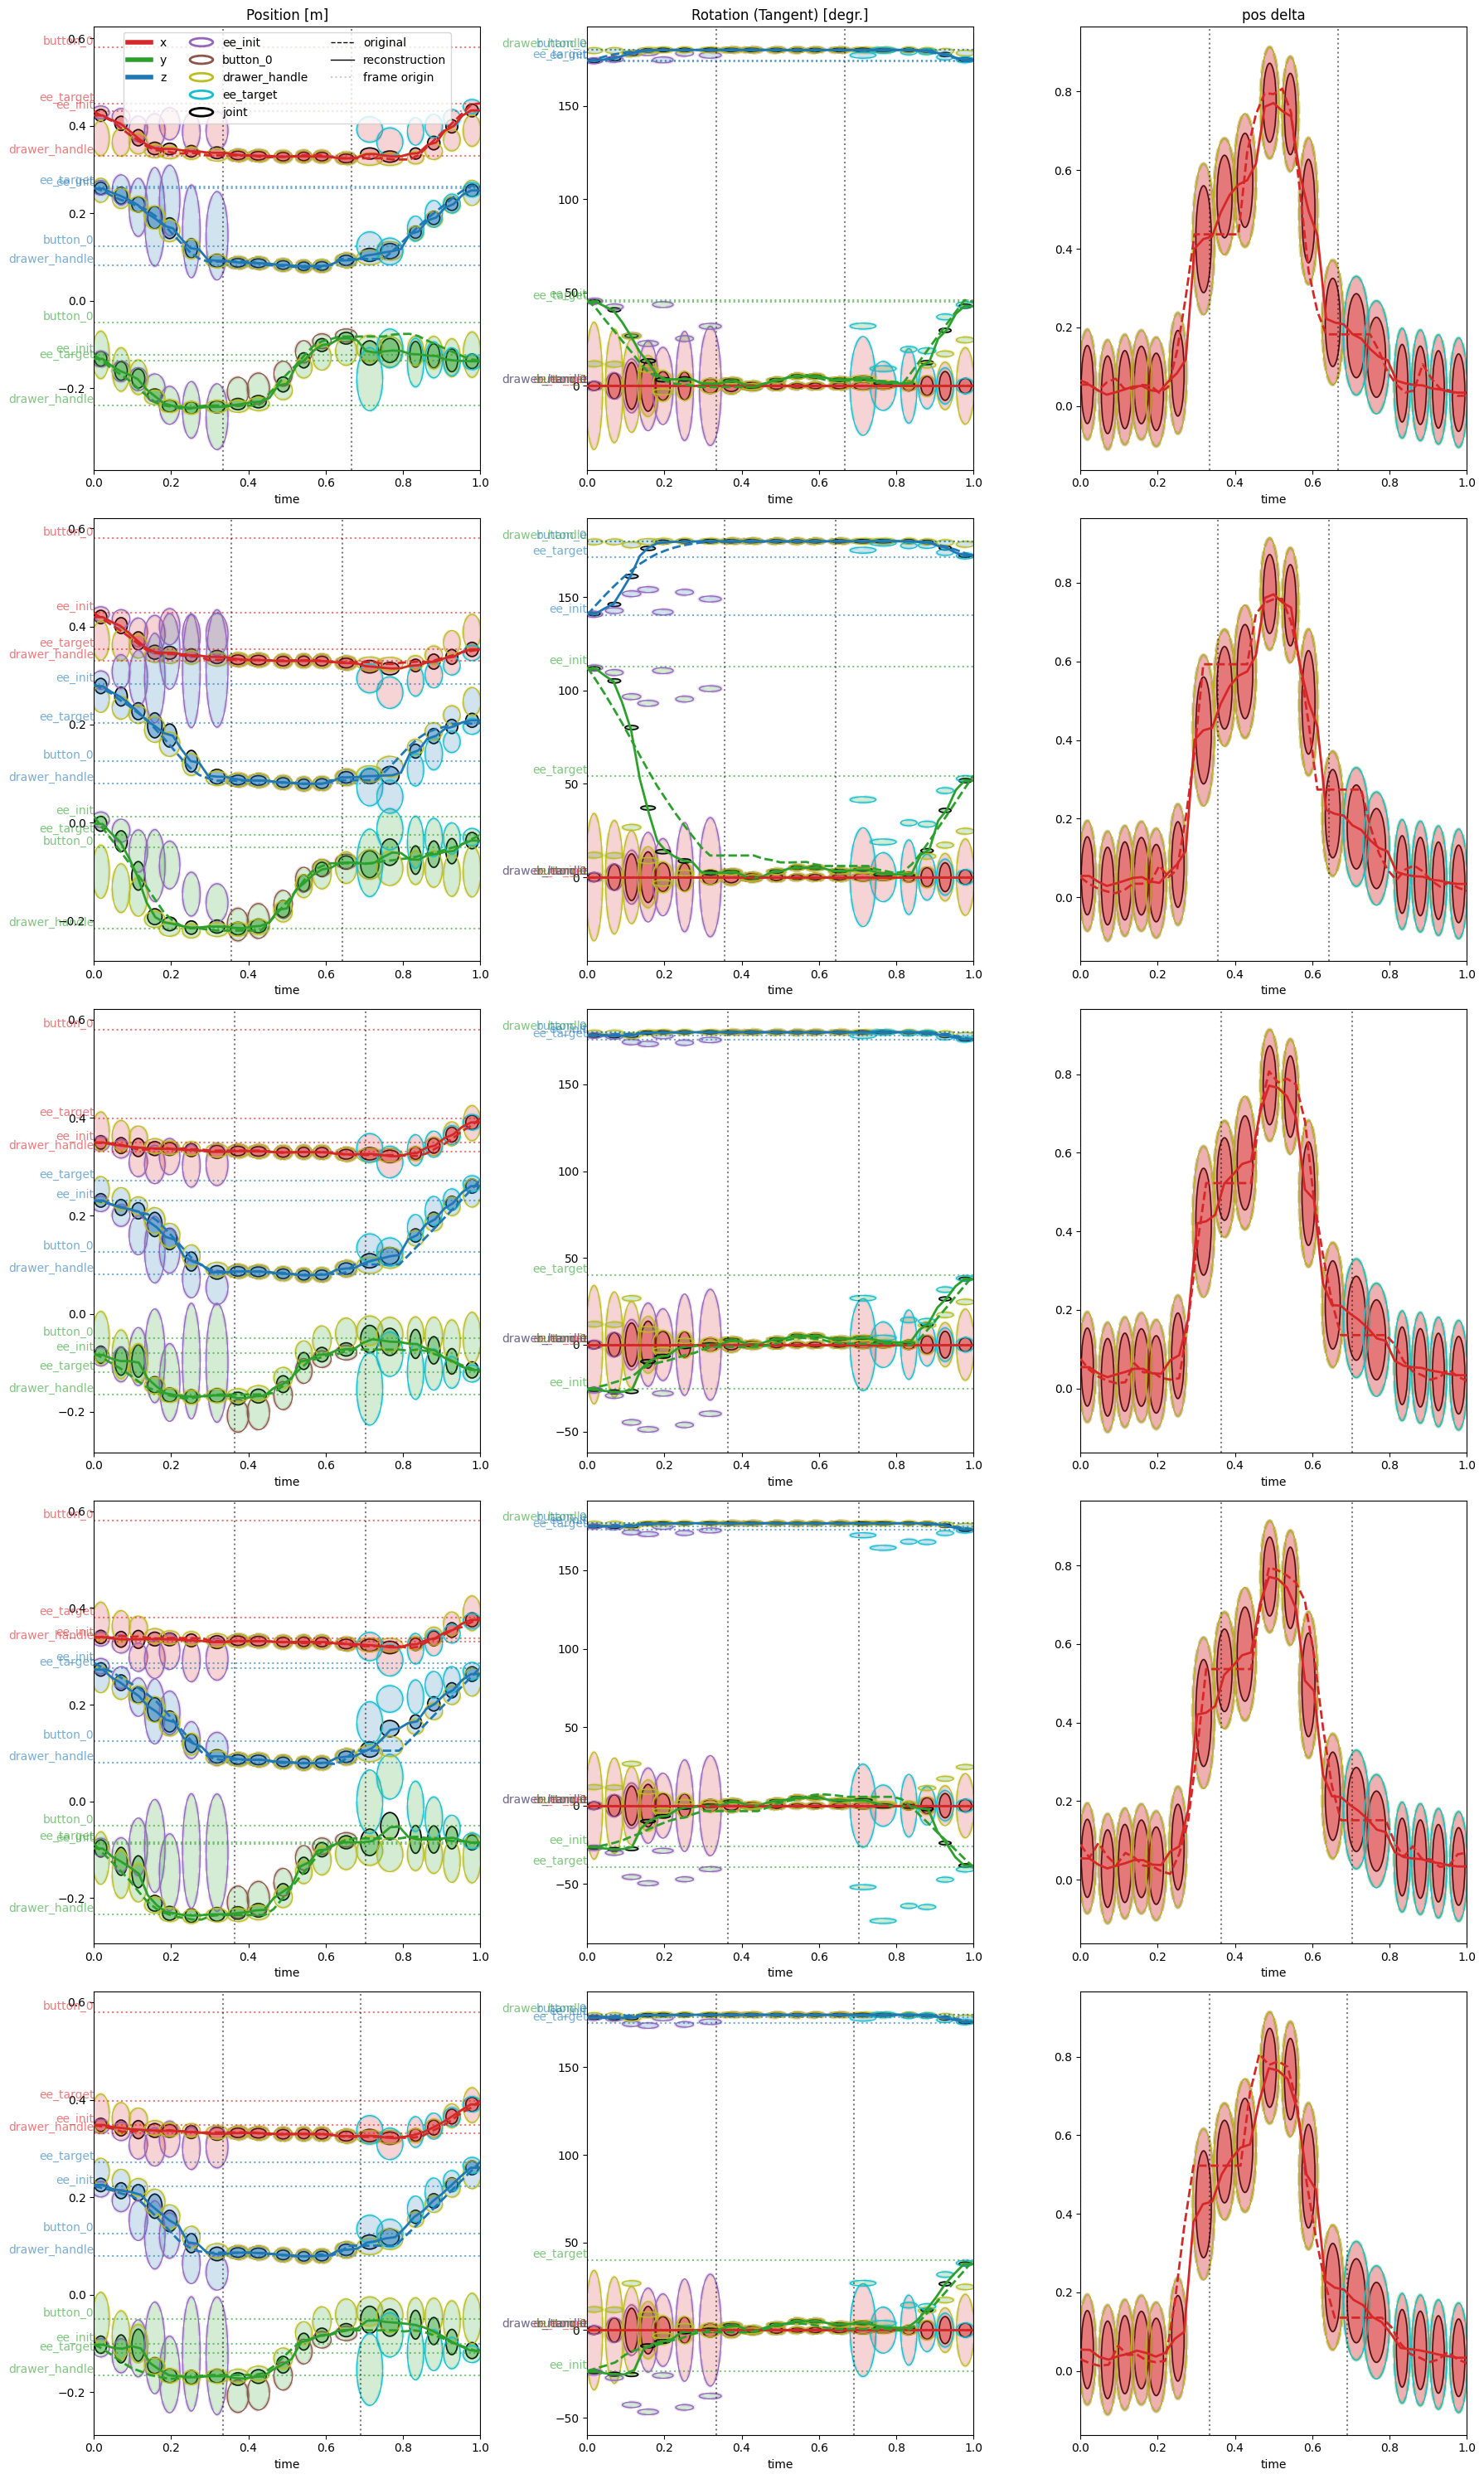

In [ ]:
agent.model.plot_reconstructions(
    seg_trans_marg_container,
    cascaded_hmms,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=True,
    equal_aspect=False,
    per_segment=False,
)

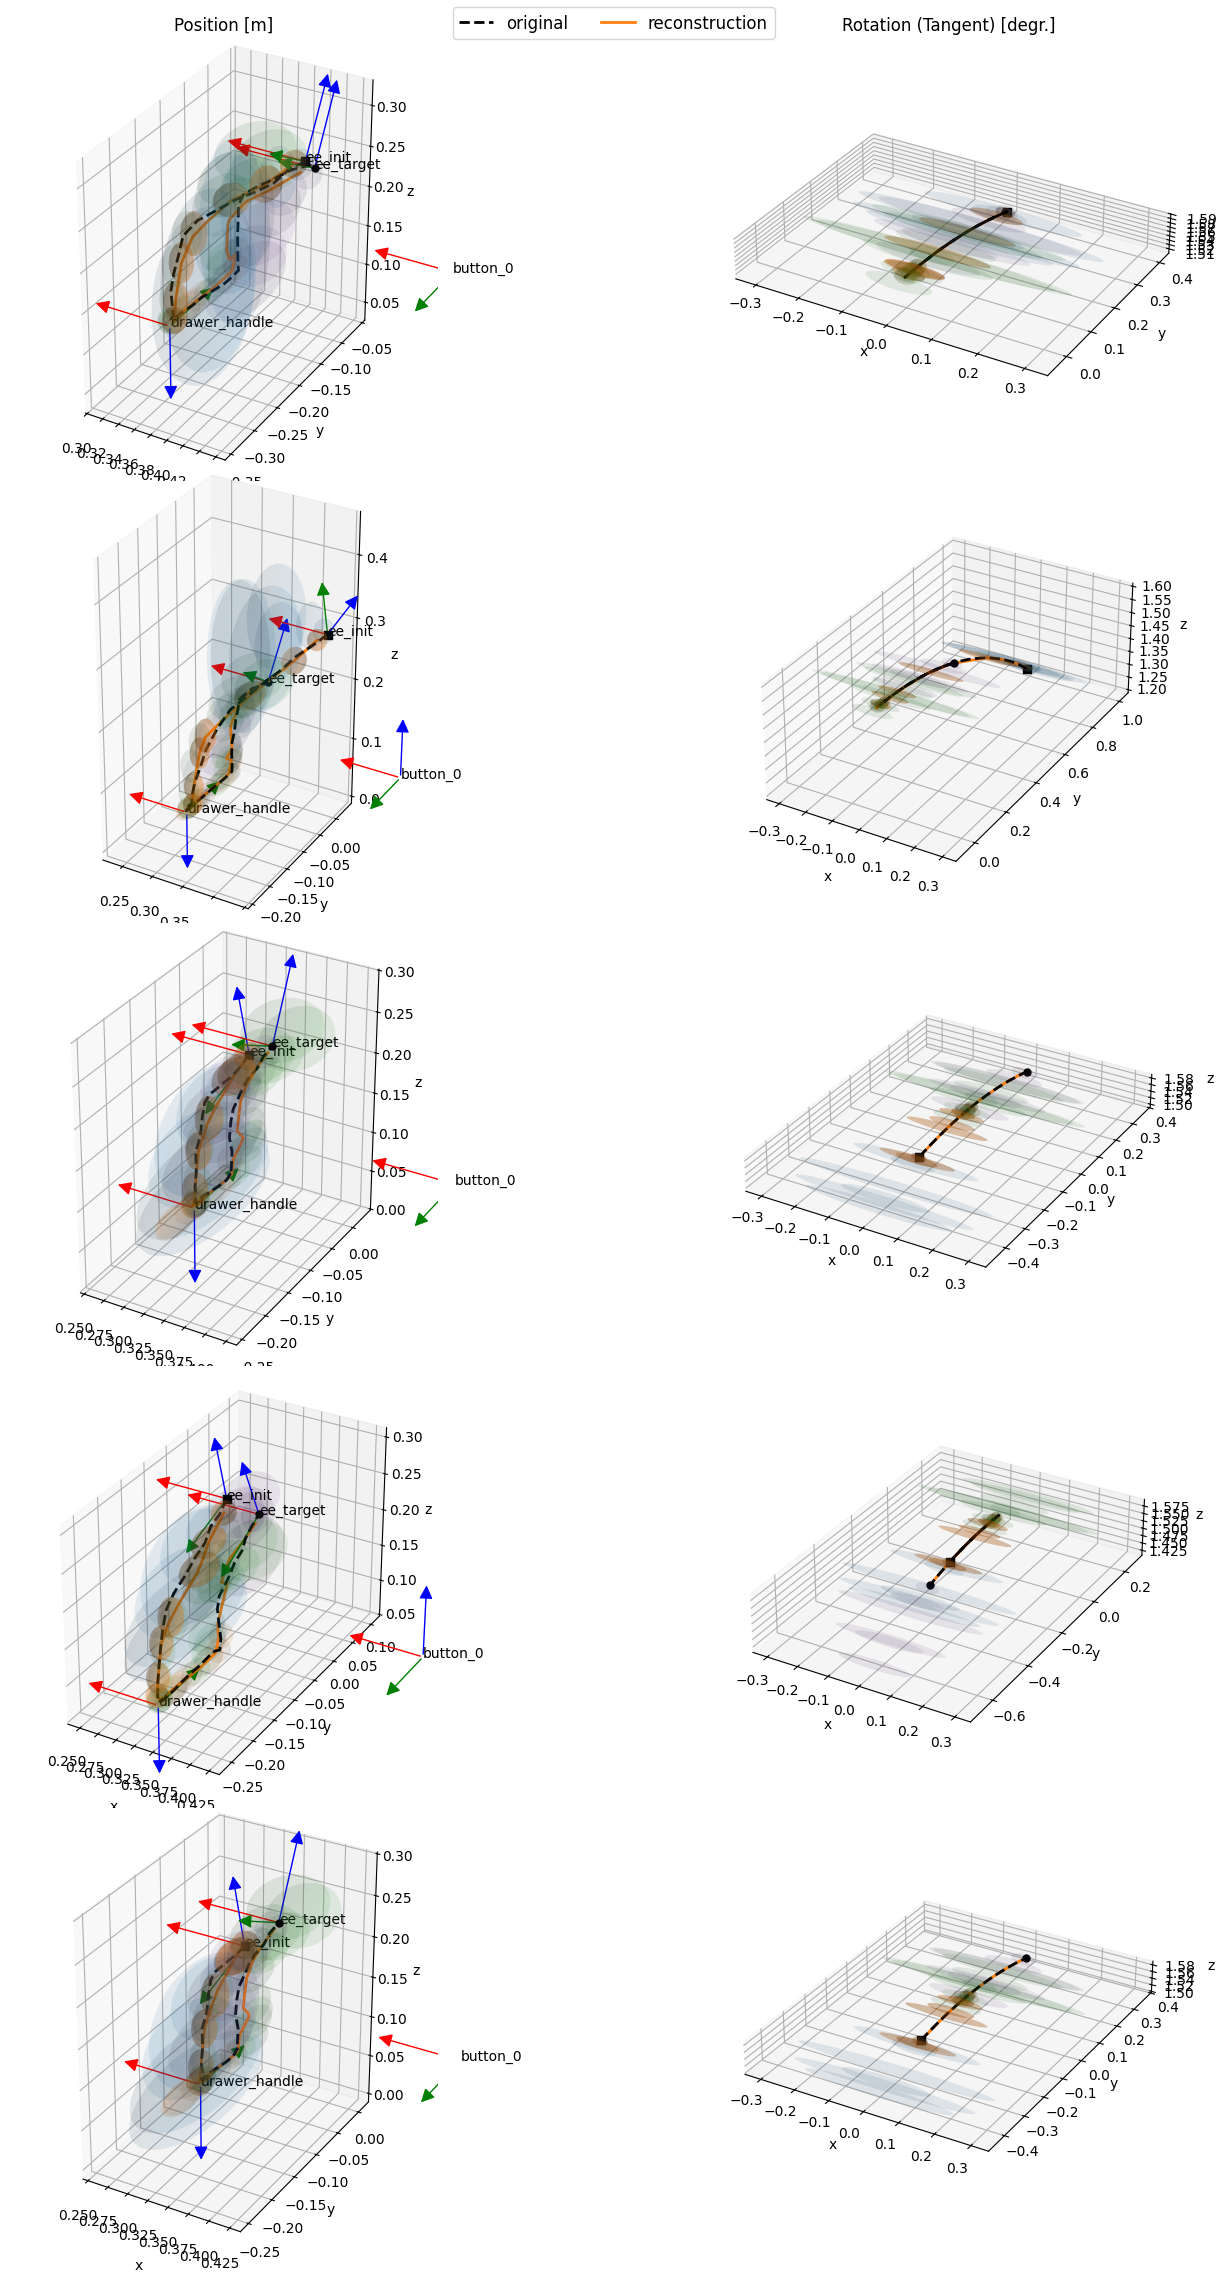

In [ ]:
agent.model.plot_reconstructions(
    seg_trans_marg_container,
    seg_joint_models,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=False,
    equal_aspect=True,
    per_segment=False,
)

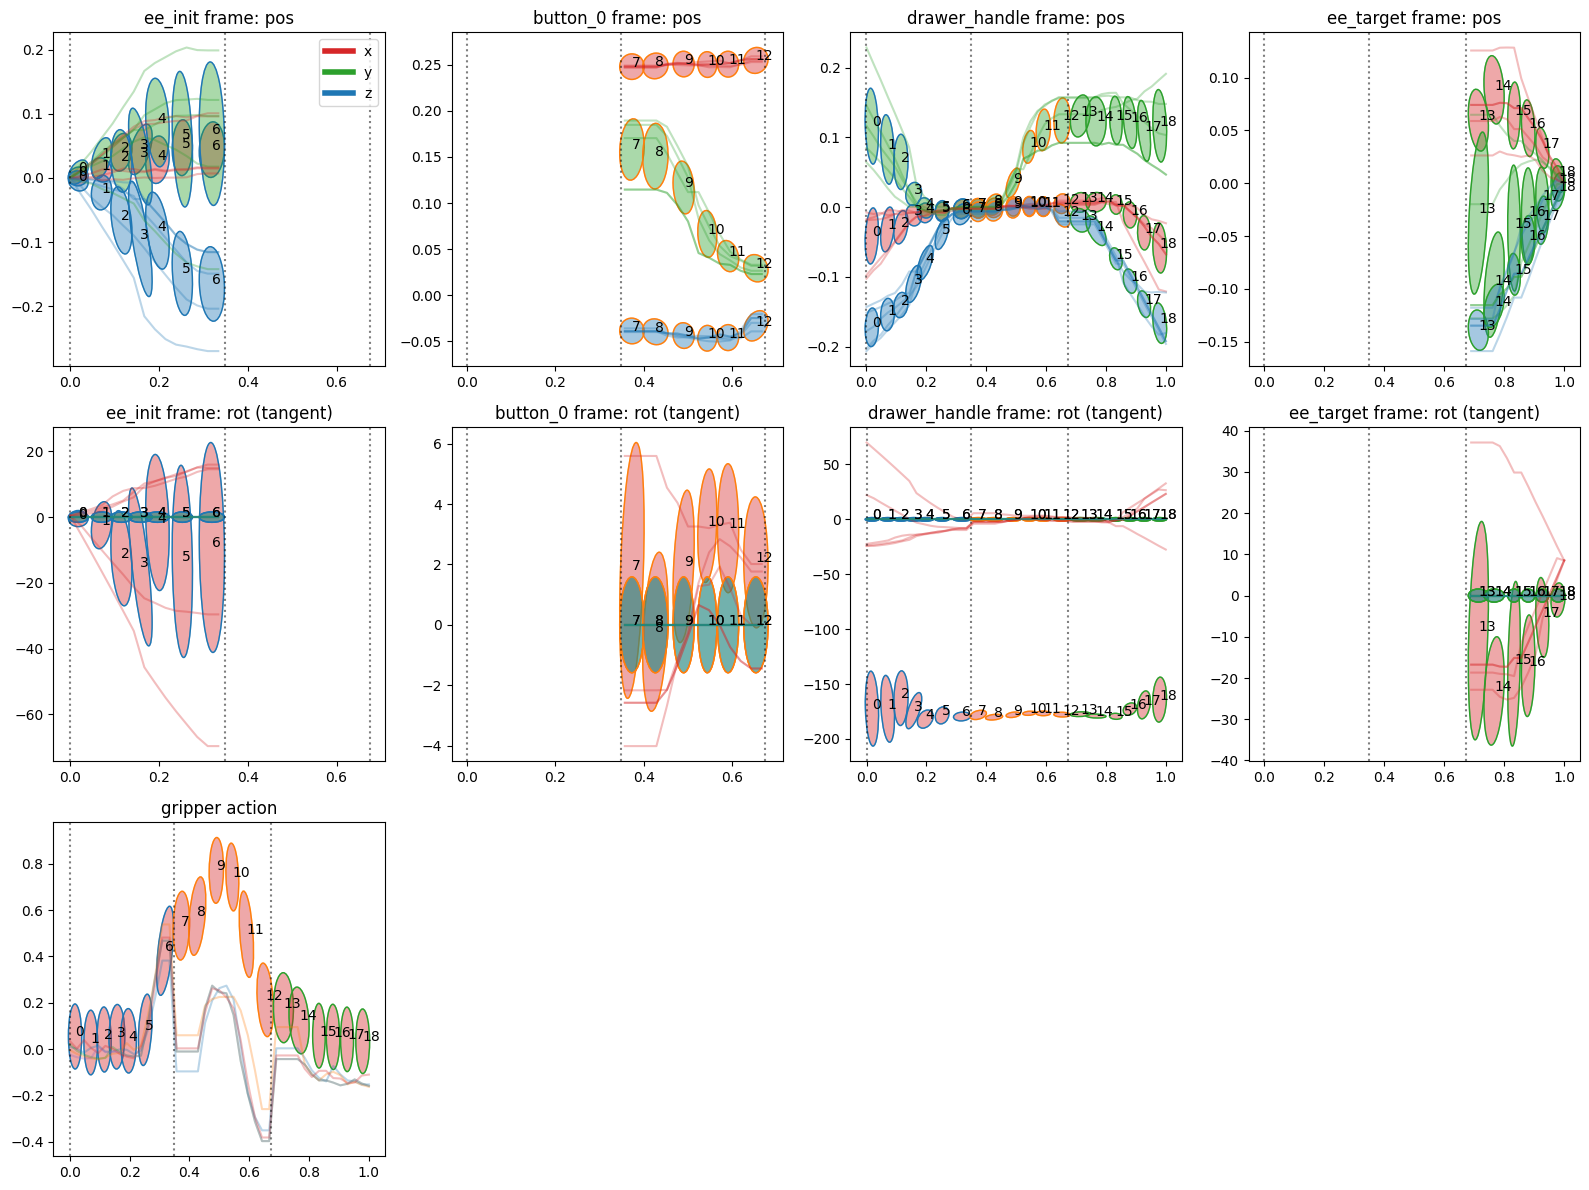

In [ ]:
agent.model.plot_model()